<a href="https://colab.research.google.com/github/Rick2898/Series_tiempo_prom_movil-/blob/main/ACTIVIDAD_1/Entrega.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" 
    alt="Open In Colab"/>
</a>

# Implementacion de Holt Winters

#### Carlos Preciado
#### Jefferson Martinez
#### Ricardo Vargas

En el siguiente notebook se desarrolla la implementacion del mejor pronostico para los proximos seis meses con ayuda del modelo de holtwinters. La data para la implementacion es: la informacion de personas ocupadas en miles de personas para las principales 13 ciudades de Colombia en su archivo <code>datosEmpleo.xlsx</code>

## Carga de librerias y data

In [ ]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose  # descomposicion 
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error




In [13]:

df_empleos= pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
df_empleos.head()
df_empleo.shape

(222, 4)

## Division train test

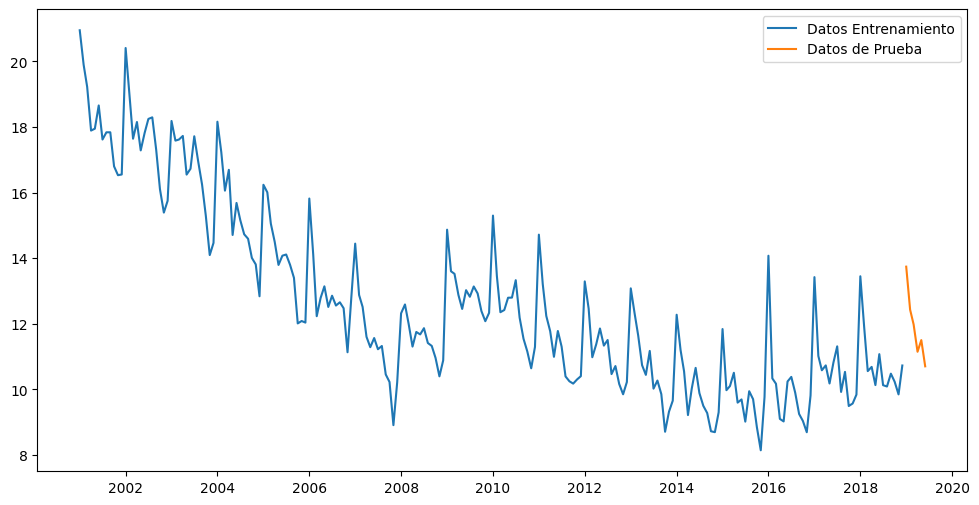

In [16]:
train_len = 216
train_td = df_empleos[["TD_13ciudades"]][:train_len]
test_td  = df_empleos[["TD_13ciudades"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(test_td,  label="Datos de Prueba")
plt.legend()
plt.show()

## Implementacion Holt Winters Aditivo

In [17]:
# ── Modelo Holt-Winters ADITIVO ──
# endog = variable que queremos pronosticar en nuestro caso el train
# error=el error se suma al modelo
# trend= muy importante ya que se refiere a que la tendencia es aditiva y aqui puede cambiarse
# seasonal = la estacionalidad en este caso tambien es aditiva 


ets_model = ETSModel(
    endog=train_td["TD_13ciudades"],
    error="add", trend="add", seasonal="add"
)
ets_result = ets_model.fit()

# Pronósticos para 14 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_add = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

            Point_forecast   lower_95   upper_95
2019-01-01       13.597583  12.553413  14.641753
2019-02-01       12.300006  11.159565  13.440447
2019-03-01       11.584349  10.351748  12.816949
2019-04-01       11.351422  10.029850  12.672994
2019-05-01       11.053782   9.645764  12.461799
2019-06-01       11.504240  10.011809  12.996671


c:\Users\Usuario\Documents\U_JAVERIANA\2_Semestre\N_SERIES_TIEMPO\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [18]:
# Parámetros estimados y RMSE
print(ets_result.alpha, ets_result.beta, ets_result.gamma)

rmse_hw_add = np.sqrt(mean_squared_error(
    test_td, preds_hw_add['Point_forecast']
))
print(rmse_hw_add)

0.4305304829938818 0.008669746661542422 5.694695170061182e-05
0.42383699090268084


## Implementacion Hotl Winters Multiplicativo

In [19]:
# ── Modelo Holt-Winters MULTIPLICATIVO ──
# endog = variable que queremos pronosticar en nuestro caso el train
# error=el error se suma al modelo
# trend= muy importante ya que se refiere a que la tendencia es aditiva y aqui puede cambiarse
# seasonal = la estacionalidad en este caso tambien es aditiva 


ets_model = ETSModel(
    endog=train_td["TD_13ciudades"],
    error="add", trend=None, seasonal="mul"
)
ets_result = ets_model.fit()

# Pronósticos para 6 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_mul = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

            Point_forecast   lower_95   upper_95
2019-01-01       13.829280  12.764354  14.961420
2019-02-01       11.816777  10.705228  12.988700
2019-03-01       11.194275  10.033615  12.535805
2019-04-01       10.961985   9.729169  12.247191
2019-05-01       10.721040   9.328199  12.079170
2019-06-01       11.374595   9.819240  12.998576


c:\Users\Usuario\Documents\U_JAVERIANA\2_Semestre\N_SERIES_TIEMPO\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [22]:
# Parámetros estimados y RMSE
print(ets_result.alpha, ets_result.gamma)

rmse_hw_mul = np.sqrt(mean_squared_error(
    test_td, preds_hw_mul['Point_forecast']
))
print(rmse_hw_mul)

0.4350987524864517 0.1595868757426322
0.5895955647170604
